In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import matplotlib.pyplot as plt
import jax.numpy as jnp

from scipy.special import ellipe as ellipe_scipy
from scipy.special import ellipeinc as ellipeinc_scipy
from scipy.special import ellipk as ellipk_scipy
from scipy.special import ellipkinc as ellipkinc_scipy
from scipy.special import elliprj, elliprc, elliprd, elliprf, elliprg
from scipy.integrate import quad

from elliptax import ellipk, ellipfinc, ellipe, ellipeinc, rj, rc, rd, rf, rg

In [2]:
def comp_plots(ax0, ax1, xs, y0s, y1s, colors, labels):
    for x, y0, y1, color, label in zip(xs, y0s, y1s, colors, labels):
        ax0.plot(x, y0, color=color, linewidth=6, label=label, alpha=0.5)
        ax0.plot(x, y1, color='k', linestyle='--')
        ax1.semilogy(x, jnp.abs(y0 - y1), '.', color=color, alpha=0.5)

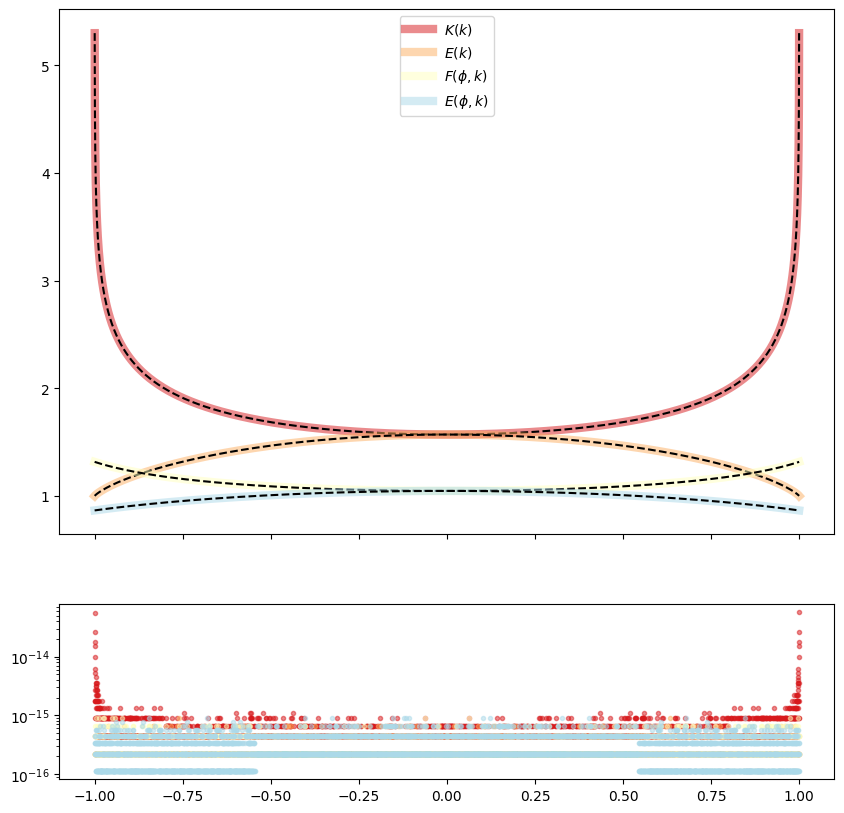

In [3]:
k = jnp.linspace(-1, 1, 10000)
phi = jnp.pi / 3.

ks = 4 * [k]
y0s = [ellipk_scipy(k * k), ellipe_scipy(k * k), ellipkinc_scipy(phi, k * k), ellipeinc_scipy(phi, k * k)]
y1s = [ellipk(k), ellipe(k), ellipfinc(phi, k), ellipeinc(phi, k)]
colors = ['#d7191c','#fdae61','#ffffbf','#abd9e9']
labels = [r"$K(k)$", r"$E(k)$", r"$F(\phi, k)$", r"$E(\phi, k)$"]

fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=(3, 1), figsize=(10, 10))

comp_plots(*axs, ks, y0s, y1s, colors, labels)
axs[0].legend()

plt.show()

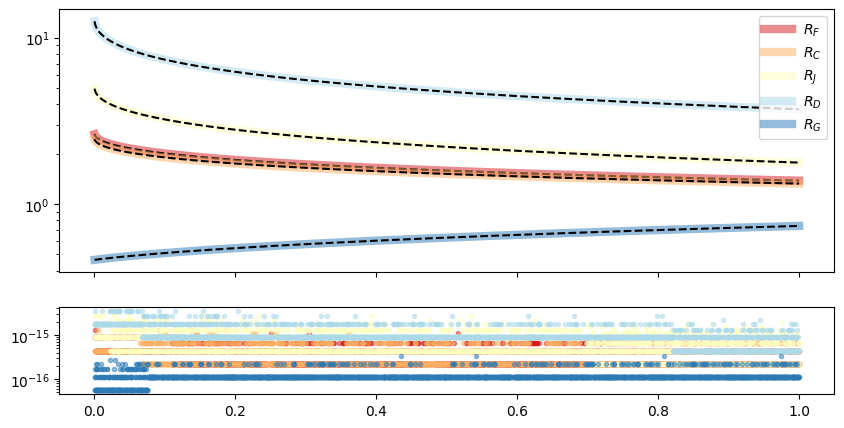

In [4]:
x = jnp.linspace(-1, 1, 10000)
y = 0.4
z = 0.3
p = 1.

xs = 5 * [x]
y0s = [elliprf(x, y, z), elliprc(x, y), elliprj(x, y, z, p), elliprd(x, y, z), elliprg(x, y, z)]
y1s = [rf(x, y, z), rc(x, y), rj(x, y, z, p), rd(x, y, z), rg(x, y, z)]
colors = ['#d7191c','#fdae61','#ffffbf','#abd9e9','#2c7bb6']
labels = [r"$R_F$", r"$R_C$", r"$R_J$", r"$R_D$", r"$R_G$"]

fig, axs = plt.subplots(2, 1, sharex=True, height_ratios=(3, 1), figsize=(10, 5))

comp_plots(*axs, xs, y0s, y1s, colors, labels)
axs[0].legend()
axs[0].set_yscale('log')

plt.show()